In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches

## MODEL

In [ ]:
import tensorflow as tf

import tensorflow as tf


def conv_bn_act(x, filters, kernel=3, stride=1):
    x = tf.keras.layers.Conv2D(filters, kernel, strides=stride,
                               padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU(0.1)(x)
    return x


def depthwise_block(x, filters, stride=1):
    x = tf.keras.layers.DepthwiseConv2D(
        3, strides=stride, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU(0.1)(x)

    x = tf.keras.layers.Conv2D(filters, 1, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU(0.1)(x)

    return x


def residual_block(x, filters):
    shortcut = x
    x = conv_bn_act(x, filters // 2, 1)
    x = conv_bn_act(x, filters, 3)

    if shortcut.shape[-1] != filters:
        shortcut = conv_bn_act(shortcut, filters, 1)

    x = tf.keras.layers.Add()([x, shortcut])
    return x


def build_yolo_lite(input_shape=(288, 576, 1)):
    inputs = tf.keras.layers.Input(shape=input_shape)

    # Stem
    x = conv_bn_act(inputs, 32, 3, 2)

    # Backbone
    x = depthwise_block(x, 64, 2)
    x = residual_block(x, 64)

    x = depthwise_block(x, 128, 2)
    x = residual_block(x, 128)
    x = residual_block(x, 128)

    x = depthwise_block(x, 256, 2)
    x = residual_block(x, 256)
    x = residual_block(x, 256)

    x = depthwise_block(x, 512, 2)
    x = residual_block(x, 512)

    # Detection head (fully convolutional)
    x = conv_bn_act(x, 256, 3)
    x = conv_bn_act(x, 128, 3)

    pred = tf.keras.layers.Conv2D(5, 1, name="raw_pred")(x)

    # Global pooling to produce single prediction
    pred = tf.keras.layers.GlobalAveragePooling2D()(pred)

    # splits
    xy_raw = tf.keras.layers.Lambda(lambda t: t[..., 0:2])(pred)
    wh_raw = tf.keras.layers.Lambda(lambda t: t[..., 2:4])(pred)
    obj_raw = tf.keras.layers.Lambda(lambda t: t[..., 4:5])(pred)

    xy = tf.keras.layers.Activation("sigmoid", name="xy")(xy_raw)
    wh = tf.keras.layers.Activation("softplus", name="wh")(wh_raw)
    obj = tf.keras.layers.Activation("sigmoid", name="obj")(obj_raw)

    output = tf.keras.layers.Concatenate(name="bbox")([xy, wh, obj])

    return tf.keras.Model(inputs, output, name="yolo_lite_binary")

In [579]:
model = build_yolo_lite((288,576,1))
model.summary()

Model: "yolo_lite_binary"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_7 (InputLayer)        [(None, 288, 576, 1)]        0         []                            
                                                                                                  
 conv2d_33 (Conv2D)          (None, 144, 288, 32)         288       ['input_7[0][0]']             
                                                                                                  
 batch_normalization_28 (Ba  (None, 144, 288, 32)         128       ['conv2d_33[0][0]']           
 tchNormalization)                                                                                
                                                                                                  
 leaky_re_lu_27 (LeakyReLU)  (None, 144, 288, 32)         0         ['batch_normali

## DATA PROCESSING

In [538]:
from PIL import Image,ImageEnhance,ImageFilter
from os import listdir
#load backgrounds
backgrounds=[]
for dir in listdir('../imgs/blockstorm/background'):
    backgrounds.append(Image.open('../imgs/blockstorm/background/'+dir).resize((576,288)))
#load characters
chars=[]
for dir in listdir('../imgs/blockstorm/character'):
    char=Image.open('../imgs/blockstorm/character/'+dir)
    #create different color characters
    r, g, b,a = char.split()
    b_half = b.point(lambda x: int(x * 0.5))
    chars.append(char)
    char = Image.merge("RGBA", (r,b,b,a))
    chars.append(char)
    char = Image.merge("RGBA", (r,g,g,a))
    chars.append(char)
    char = Image.merge("RGBA", (b,b,r,a))
    chars.append(char)
    char = Image.merge("RGBA", (b,b,g,a))
    chars.append(char)
#load objects
objects=[]
for dir in listdir('../imgs/blockstorm/object'):
    objects.append(Image.open('../imgs/blockstorm/object/'+dir))

ui=Image.open('../imgs/blockstorm/ui.png').resize((324,182))
validset=[]
for dir in listdir('../imgs/blockstorm/validation'):
    validset.append(Image.open('../imgs/blockstorm/validation/'+dir))

In [19]:
def ypreds_scale(ypred,div=True):
    x,y,dx,dy,lbl=ypred
    w,h=backgrounds[0].size
    if div:
        x/=w
        y/=h
        dx/=w
        dy/=h
    else:
        x*=w
        y*=h
        dx*=w
        dy*=h
    return (x,y,dx,dy,lbl)

In [1099]:
#x and y between image box
def bounder(val,minval,maxval):
    val=min(maxval,val)
    val=max(minval,val)
    return val
#rectangle between image box
def thresholder(val,dval,minval,maxval):
    dval=min(dval,maxval-val)
    dval=min(dval,dval+val)
    return dval


#class that procedurally generates new images starting from base backgrounds, chars, objects
class ImageGenerator:
    def __init__(self,backgrounds, characters, objects,ui):
        self.backgrounds=backgrounds
        self.characters=characters
        self.objects=objects
        self.ui=ui
    
    #merge background with another image (char/ui/object)
    def merger(self,background,topaste,x,y):
        background.paste(topaste, (x, y), mask=topaste.getchannel(3))
    
    #char_p: probability of character not appearing
    def new_image(self,char_p=0.1,object_p=0.6,bg_p=0.7,bg_p_noise=0.5,augmentation=True):
        #get random background
        idxbg=np.random.randint(0,len(self.backgrounds))
        background=self.backgrounds[idxbg].copy()
        img=background.convert('RGBA')
        #default x,y,dx,dy,label
        x,y,dx,dy,label=(0,0,0,0,0)
        
        #with probability 1-p, insert character
        if np.random.uniform()>char_p:
            idxchar=np.random.randint(0,len(chars))
            char=chars[idxchar].copy()
            offx=np.random.randint(-30,460)
            offy=np.random.randint(-30,160)
            #augmentation
            #scaling factor
            factor=np.random.uniform(0.15,1)
            h,w=char.size
            char=char.resize((int(h*factor),int(w*factor)))
            if augmentation:
                char=self.transform(char,p=0.0)
            self.merger(img,char,offx,offy)
            w,h=char.size
            w=thresholder(offx,w,0,576)
            h=thresholder(offy,h,0,288)
            offx=bounder(offx,0,576)
            offy=bounder(offy,0,288)
            x,y,dx,dy,label=(offx,offy,w,h,1)
            
        
        #insert object with probability 1-p
        if np.random.uniform()>object_p:
            offx=np.random.randint(-30,460)
            offy=np.random.randint(-30,160)
            factor=np.random.uniform(0.1,0.3)
            idobj=np.random.randint(low=0,high=len(self.objects))
            obj=self.objects[idobj]
            h,w=obj.size
            obj=obj.resize((int(h*factor),int(w*factor)))
            self.merger(img,obj,offx,offy)

        if augmentation:
            #salt and pepper
            if np.random.uniform()>bg_p_noise:
                val=np.random.uniform(low=0.001,high=0.03)
                img=self.add_salt_pepper(img,amount=val)
            #gaussian noise
            if np.random.uniform()>bg_p_noise:
                img=self.add_gaussian_noise(img)
            #flip entire image with probability 1-p
            if np.random.uniform()>bg_p:
                img=img.transpose(Image.FLIP_LEFT_RIGHT)
                #get the right rectangle coordinates
                if label==1:
                    x=576-x-dx
            elif np.random.uniform()>bg_p:
                img=img.transpose(Image.FLIP_TOP_BOTTOM)
                #get the right coordinates
                if label==1:
                    y=288-y-dy
        x+=int(dx/2)
        y+=int(dy/2)
        truey=(x,y,dx,dy,label)
        return img,truey
    
    def transform(self,img,p=0.4):
        #color jitter
        if np.random.uniform()>p:
            brightness=0.4
            img = ImageEnhance.Brightness(img).enhance(1.0 + np.random.uniform(-brightness, brightness))
            contrast=0.4
            img = ImageEnhance.Contrast(img).enhance(1 + np.random.uniform(-contrast, contrast))
            saturation=0.4
            img = ImageEnhance.Color(img).enhance(1 + np.random.uniform(-saturation, saturation))
        
        #blur
        if np.random.uniform()>p:
            r = np.random.uniform(0, 1)
            img=img.filter(ImageFilter.GaussianBlur(r))

        #opacity 
        if np.random.uniform()>p:
            alpha = img.split()[-1]
            factor = np.random.uniform(0.7, 0.9)
            alpha = alpha.point(lambda p: int(p * factor))
            img.putalpha(alpha)
        return img
    
    def add_salt_pepper(self,img, amount=0.01):
        arr = np.array(img)
        noisy = arr.copy()

        num_pixels = int(amount * arr.shape[0] * arr.shape[1])

        # salt (white)
        coords = (
            np.random.randint(0, arr.shape[0], num_pixels),
            np.random.randint(0, arr.shape[1], num_pixels),
        )
        noisy[coords] = 255

        # pepper (black)
        coords = (
            np.random.randint(0, arr.shape[0], num_pixels),
            np.random.randint(0, arr.shape[1], num_pixels),
        )
        noisy[coords] = 0

        return Image.fromarray(noisy)

    def add_gaussian_noise(self,img, mean=0, std=10):
        arr = np.array(img).astype(np.float32)

        noise = np.random.normal(mean, std, arr.shape)
        noisy = arr + noise

        noisy = np.clip(noisy, 0, 255).astype(np.uint8)
        return Image.fromarray(noisy)

In [21]:
def display_img_rect(img,truey):
    plt.imshow(img)
    x,y,dx,dy,_=truey

    rect = patches.Rectangle((x-int(dx/2), y-int(dy/2)),dx,dy,linewidth=2,edgecolor='red',facecolor='none')

    plt.gca().add_patch(rect)
    plt.plot(x,y,'o',markersize=10,fillstyle='none')
    plt.axis('off')
    plt.show()

In [22]:
gen=ImageGenerator(backgrounds, chars,objects,ui)

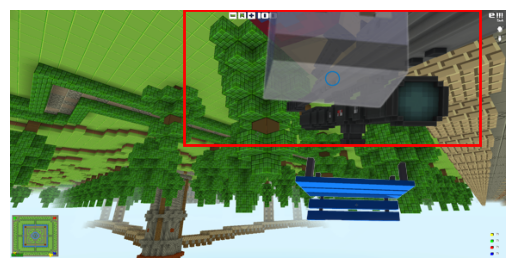

In [23]:
img,truey=gen.new_image()
display_img_rect(img,truey)

In [24]:
def predict(model,img,scale=255):
    predicted=model.predict(np.array(img)[None,...]/scale)[0]
    return predicted

1/1 [==============================] - 0s 150ms/step
(291.6463279724121, 144.14268493652344, 402.6966133117676, 196.2396297454834, 0.5155214)


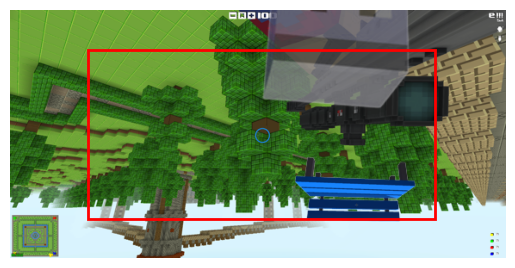

In [25]:
yhat=predict(model,img.convert('RGB'))
yhat=ypreds_scale(yhat,div=False)
print(yhat)
display_img_rect(img,yhat)

In [590]:
import math


def ciou_loss_per_sample(box_true, box_pred, eps=1e-7):
    x_p, y_p, w_p, h_p = tf.split(box_pred, 4, axis=-1)
    x_t, y_t, w_t, h_t = tf.split(box_true, 4, axis=-1)

    # corners
    x1_p = x_p - w_p / 2
    y1_p = y_p - h_p / 2
    x2_p = x_p + w_p / 2
    y2_p = y_p + h_p / 2

    x1_t = x_t - w_t / 2
    y1_t = y_t - h_t / 2
    x2_t = x_t + w_t / 2
    y2_t = y_t + h_t / 2

    # intersection
    xi1 = tf.maximum(x1_p, x1_t)
    yi1 = tf.maximum(y1_p, y1_t)
    xi2 = tf.minimum(x2_p, x2_t)
    yi2 = tf.minimum(y2_p, y2_t)

    inter_w = tf.maximum(xi2 - xi1, 0.0)
    inter_h = tf.maximum(yi2 - yi1, 0.0)
    inter_area = inter_w * inter_h

    # union
    area_p = w_p * h_p
    area_t = w_t * h_t
    union = area_p + area_t - inter_area
    iou = inter_area / (union + eps)

    # center distance
    center_dist = (x_p - x_t) ** 2 + (y_p - y_t) ** 2

    # enclosing box
    x1_c = tf.minimum(x1_p, x1_t)
    y1_c = tf.minimum(y1_p, y1_t)
    x2_c = tf.maximum(x2_p, x2_t)
    y2_c = tf.maximum(y2_p, y2_t)

    c_diag = (x2_c - x1_c) ** 2 + (y2_c - y1_c) ** 2 + eps

    # aspect ratio term
    v = (4.0 / (math.pi ** 2)) * tf.square(
        tf.math.atan(w_t / (h_t + eps)) -
        tf.math.atan(w_p / (h_p + eps))
    )

    alpha = v / (1.0 - iou + v + eps)

    ciou = iou - (center_dist / c_diag + alpha * v)

    loss = 1.0 - ciou

    return tf.squeeze(loss, axis=-1)


def yolo_lite_loss(y_true, y_pred):

    # split
    box_true = y_true[..., 0:4]
    obj_true = y_true[..., 4:5]

    box_pred = y_pred[..., 0:4]
    obj_pred = y_pred[..., 4:5]

    # ----- box loss -----
    ciou = ciou_loss_per_sample(box_true, box_pred)

    obj_mask = tf.squeeze(obj_true, axis=-1)

    l1 = tf.reduce_sum(tf.abs(box_true - box_pred), axis=-1) / 4.0

    box_loss = (0.5 * ciou + 0.5 * l1) * obj_mask

    # ----- IoU-aware objectness -----
    iou_target = 1.0 - ciou
    iou_target = tf.stop_gradient(iou_target)

    obj_target = obj_true * tf.expand_dims(iou_target, axis=-1)

    obj_loss = tf.keras.losses.binary_crossentropy(obj_target, obj_pred)

    # background weighting
    obj_loss = obj_true * obj_loss + 0.25 * (1.0 - obj_true) * obj_loss

    # ----- weights -----
    lambda_box = 5.0
    lambda_obj = 1.0

    total = lambda_box * box_loss + lambda_obj * obj_loss

    return tf.reduce_mean(total)

In [27]:
model=tf.keras.saving.load_model('model/model_yolo.keras')

OSError: No file or directory found at model/model_yolo.keras

In [48]:
class DataGenerator(tf.keras.utils.Sequence):
    def __init__(self, backgrounds, chars,length,batchsize=1,augmentation=1,imgp=0.2):
        self.gen=ImageGenerator(backgrounds,chars,objects,ui)
        self.length=length
        self.batchsize=batchsize
        p,_=self.gen.new_image(augmentation=0)
        self.h,self.w=p.size
        self.aug=augmentation
        self.imgp=imgp

    def __len__(self):
        return int(self.length/self.batchsize)

    def __getitem__(self, idx):
        batchys=np.zeros((self.batchsize,5),dtype=np.float16)
        batchimgs=np.zeros((self.batchsize,self.w,self.h,1),dtype=np.float16)
        for i in range(self.batchsize):
            orig, truey = self.gen.new_image(augmentation=self.aug,object_p=0.3,char_p=self.imgp)
            truey=ypreds_scale(truey,div=True)
            

            img = np.array(orig.convert('L'), dtype=np.float16) / 255.0
            #img = np.array(orig.convert('RGB'), dtype=np.float16) / 255.0
            truey = np.array(truey, dtype=np.float16) 
            

            batchimgs[i,:]=img[...,None]
            batchys[i,:]=truey 
        return batchimgs, batchys 

### First run without augmentation

In [1031]:
optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5)
model.compile(optimizer=optimizer,loss=yolo_lite_loss)
trainset = DataGenerator(backgrounds,chars,256,batchsize=8,augmentation=0,imgp=0.2)

In [1032]:
history = model.fit(trainset, epochs=1)

32/32 [==============================] - 20s 434ms/step - loss: 1.2661


### Second run with augmentation

In [1045]:
optimizer = tf.keras.optimizers.Adam(learning_rate=2e-5)
model.compile(optimizer=optimizer,loss=yolo_lite_loss)
trainset = DataGenerator(backgrounds,chars,256,batchsize=8,augmentation=1,imgp=0.10)

In [1068]:
history = model.fit(trainset, epochs=50)

Epoch 1/50
32/32 [==============================] - 13s 411ms/step - loss: 1.5994
Epoch 2/50
32/32 [==============================] - 13s 400ms/step - loss: 1.6684
Epoch 3/50
32/32 [==============================] - 13s 399ms/step - loss: 1.5730
Epoch 4/50
32/32 [==============================] - 13s 406ms/step - loss: 1.6553
Epoch 5/50
32/32 [==============================] - 13s 409ms/step - loss: 1.6375
Epoch 6/50
32/32 [==============================] - 14s 424ms/step - loss: 1.6947
Epoch 7/50
32/32 [==============================] - 13s 403ms/step - loss: 1.6846
Epoch 8/50
32/32 [==============================] - 13s 405ms/step - loss: 1.6242
Epoch 9/50
32/32 [==============================] - 13s 397ms/step - loss: 1.6386
Epoch 10/50
32/32 [==============================] - 13s 407ms/step - loss: 1.6176
Epoch 11/50
32/32 [==============================] - 13s 399ms/step - loss: 1.6262
Epoch 12/50
32/32 [==============================] - 13s 402ms/step - loss: 1.6938
Epoch 13/50
3

In [1101]:
model.save('../model/model_yolo_v2.keras')

In [1100]:
gen=ImageGenerator(backgrounds,chars,objects,ui)

1/1 [==============================] - 0s 40ms/step
[0.5904238  0.25385398 0.17470913 0.4674042  0.50835794]
(347, 85, 100, 168, 1)


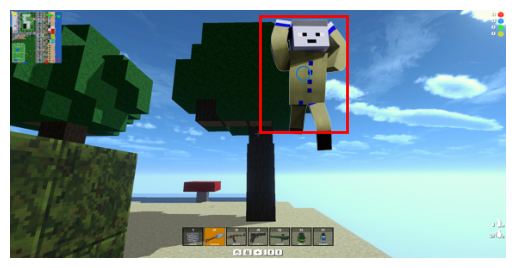

In [1223]:
origimg,ytrue=gen.new_image(augmentation=0,char_p=0.0,object_p=2)
img=origimg.convert('L')
predicted=predict(model,img,scale=255)
print(predicted)
yhat=ypreds_scale(predicted,div=False)
print(ytrue)
display_img_rect(origimg,yhat)

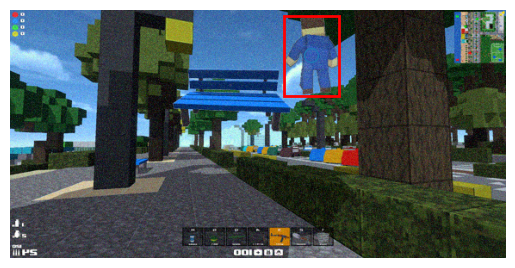

In [66]:
display_img_rect(origimg,ytrue)

In [67]:
ytrue, yhat

((349, 52, 63, 93, 1),
 (472.9640007019043,
  205.15601348876953,
  0.015244905953295529,
  50579.7890625,
  0.4072979))